In [29]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from sigfig import round
%run ./HFIR_Experiment_Functions.ipynb

In [2]:
#slow = pd.read_csv('nsrgsc_20240609_1_18.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240610_1_3.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240610_1_6.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240611_1_6.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240611_1_7.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240611_1_5.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240612_7_1.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240613_2_1.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240613_2_1_full.csv', header=None)
slow = pd.read_csv('nsrgsc_20240614_3_1.csv', header=None)

In [33]:
#begin=1500
#begin=10000
#end=len(slow)-5000
#end=10600
#end=2500
#end=len(slow)
begin=10
#start=10
end=len(slow)

TUSBR = np.float64(slow[2][begin:end])
TRADS = np.float64(slow[3][begin:end])
TDSTR = np.float64(slow[4][begin:end])
TDSBL = np.float64(slow[5][begin:end])
temps = [TUSBR,TDSTR,TDSBL]
avg_temps=(TUSBR+TDSTR+TDSBL)/3
sample_temps=(TUSBR+TDSTR)/2
temp=TUSBR

#Fluxgate readouts, making the upstream ones negative and dividing x,y,z by 4:
field1 = np.float64(slow[18][begin:end])
field2 = np.float64(slow[19][begin:end])
field3 = np.float64(slow[20][begin:end])
field4 = np.float64(slow[21][begin:end])
field5 = np.float64(slow[22][begin:end])
fieldx = np.float64(slow[23][begin:end])
fieldy = np.float64(slow[24][begin:end])
fieldz = np.float64(slow[25][begin:end])
error = np.float64(slow[6][begin:end])
index = np.float64(slow[0][begin:end])
time = np.float64(slow[1][begin:end])

fields=[field1,field2,field3,field4,field5,fieldx,fieldy,fieldz]
places=["DSTL", "DSTR", "DSBR", "USTL", "DSBL", "USTR", "USBR", "USBL"]

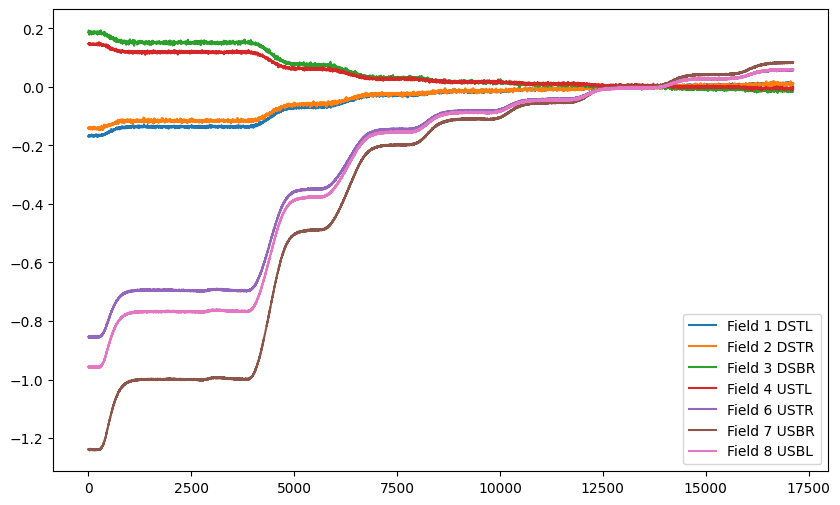

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

#plotting all but field 5

for i in [0,1,2,3,5,6,7]:
    ax.plot(time,fields[i],label = f"Field {i+1} {places[i]}")


ax.legend(loc="lower right")

In [35]:
field1_sweep=np.mean(fields[0][12500:13000])
field1_sweep

-0.000289354

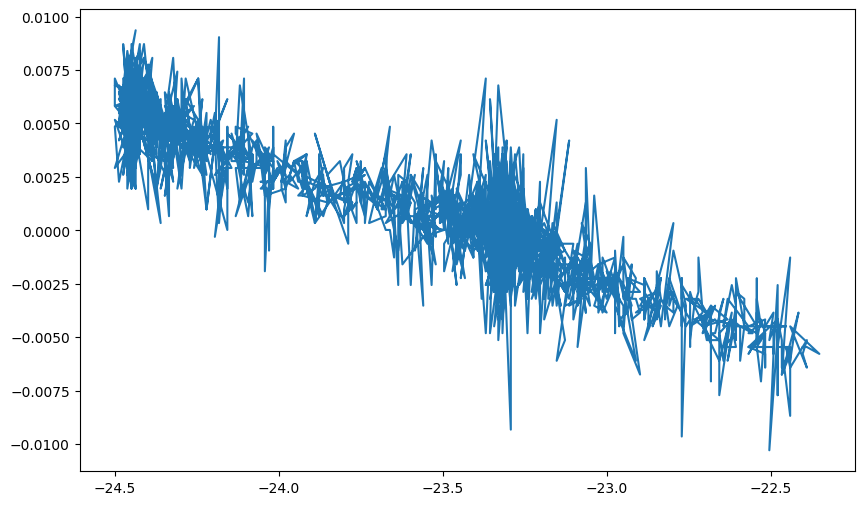

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sample_temps[12000:15000],fields[0][12000:15000])



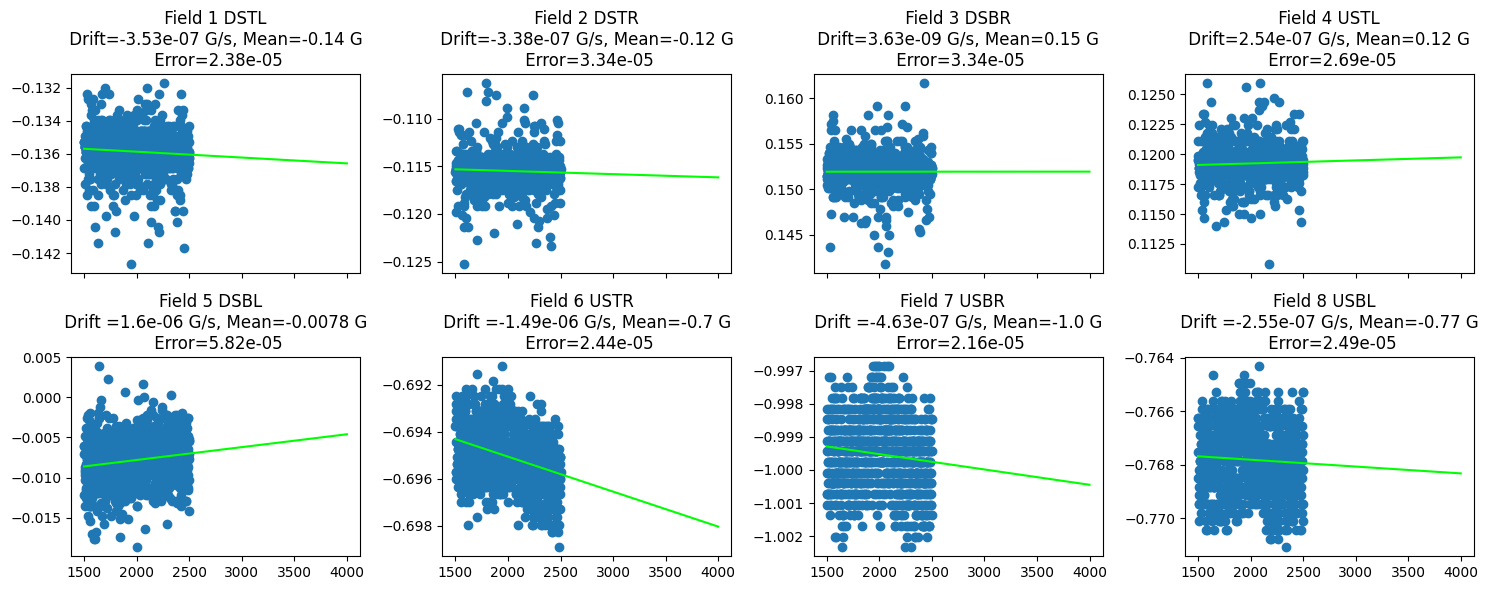

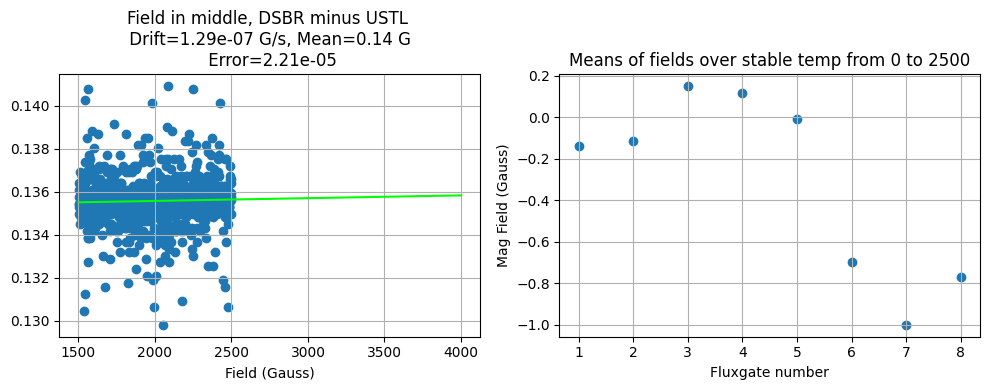

In [23]:
#x,y=time,((fieldx-fieldz)-(field1+field3))/2

#Calculating slope aka drift:

def plot_fields(time,fields,start,cutoff):

    means=[]
    sterrs=[]
    index=[]
    
    fig,axs = plt.subplots(2,4,figsize=(15, 6),sharex=True)

    
    for i in [0,1,2,3]:
        x=time[start:cutoff]
        y=fields[i][start:cutoff]
        
        axs[0,i].scatter(x,y)
        
        z=np.arange(start+begin,cutoff+begin)
        fit=np.polyfit(x,y,1,full=True)
        
        slope = fit[0][0]
        sterr = np.std(y)/np.sqrt(cutoff-start) #standard error (aka std of the mean): divide std by sqrt sample size
        axs[0,i].plot(z,fit[0][0]*z+fit[0][1], color="lime")
        axs[0,i].set_title(f" Field {i+1} {places[i]} \n Drift={round(slope,sigfigs=3)} G/s, Mean={round(np.mean(y),sigfigs=2)} G \n Error={round(sterr,sigfigs=3)}")
        means.append(np.mean(y))
        sterrs.append(sterr) 
        index.append(i+1)
    
    for i in [4,5,6,7]:
        x = time[start:cutoff]
        y = fields[i][start:cutoff]

        axs[1,i-4].scatter(x,y)
        z=np.arange(start+begin,cutoff+begin)
        fit=np.polyfit(x,y,1,full=True)

        slope = fit[0][0]
        sterr = np.std(y)/np.sqrt(cutoff-start)
        
        axs[1,i-4].plot(z,slope*z+fit[0][1], color="lime")
        axs[1,i-4].set_title(f"Field {i+1} {places[i]}  \n Drift ={round(slope,sigfigs=3)} G/s, Mean={round(np.mean(y),sigfigs=2)} G \n Error={round(sterr,sigfigs=3)}")
        means.append(np.mean(y))
        sterrs.append(sterr)
        index.append(i+1)
    

    
    fig.tight_layout()
    
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10, 4))

    x,y=time[start:cutoff],(field3[start:cutoff]+field4[start:cutoff])/2
    ax1.scatter(x,y)
    ax1.grid()
    z=np.arange(start+begin,cutoff+begin)
    fit=np.polyfit(x,y,1,full=True)

    slope = fit[0][0]
    sterr = np.std(y)/np.sqrt(cutoff-start)
    
    ax1.plot(z,fit[0][0]*z+fit[0][1], color="lime")
    ax1.set_title(f"Field in middle, DSBR minus USTL \n Drift={round(fit[0][0],sigfigs=3)} G/s, Mean={round(np.mean(y),sigfigs=2)} G \n Error={round(sterr,sigfigs=3)}")
    ax1.set_xlabel("Time (s)")
    ax1.set_xlabel("Field (Gauss)")

    ax2.set_title(f"Means of fields over stable temp from {start} to {cutoff}")
    ax2.scatter(index,means)
    #ax2.errorbar(index,means,sterr)
    ax2.grid()
    ax2.set_xlabel("Fluxgate number")
    ax2.set_ylabel("Mag Field (Gauss)")
    fig.tight_layout()

plot_fields(time,fields,start=0,cutoff=end)

#residual divided by N-1 gives variance, square root gives sd

#Fix the problem that arises when index and time arent equal



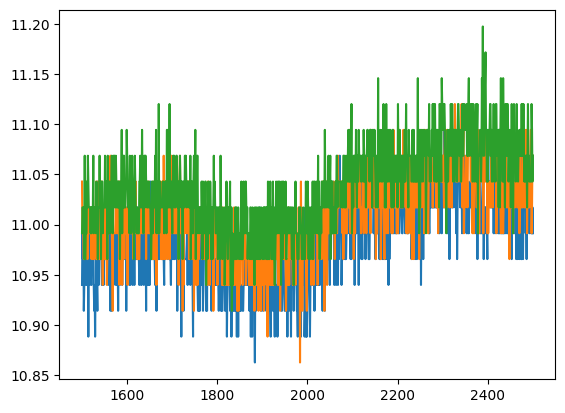

In [24]:
for i in np.arange(len(temps)):
    plt.plot(time,temps[i])

#np.mean(TDSBL[16500:16600])

In [1039]:
(temps[0][7000]+temps[1][7000]+temps[2][7000])/3

-20.07283466666667

In [1212]:
gen_cutoff(time,avg_temps,fields,n=60)

[120, 3424, 5274, 7507, 9545, 11463, 13562, 15442, 16607]

In [1353]:
n=60
temp=temps[0]
cutoffs=gen_cutoff(time,temp,fields,n)
field_avg(time,fieldy,cutoffs,-22.5,n)[1]

[0.309950925,
 0.24917738333333334,
 0.12304866250000002,
 0.049470737499999994,
 0.027247683333333335,
 0.013271566666666667,
 -0.00024824166666666665,
 -0.0105833625,
 -0.020254187500000003]

slope= 0.18984816598998863
slope times .0045 gauss =  0.0008543167469549488
slope div -.1376 lockin =  -0.7247897248965584
slope div -.138 lockin =  -0.7268966717712577
slope div -.1385 lockin =  -0.7295303553646318


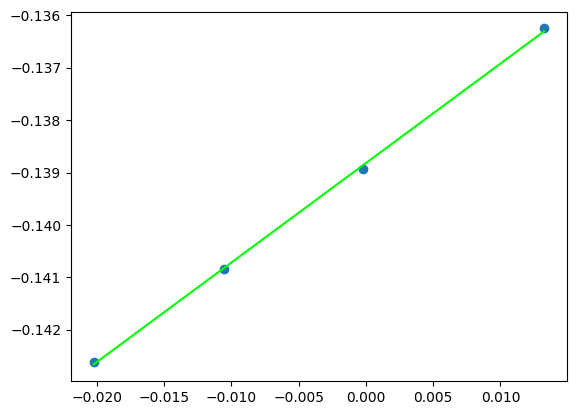

In [1505]:
field1_sweep=field_avg(time,fieldy,cutoffs,-22.5,n)[1][5:10]
lock_in=[-.13625,-.13894,-.14085,-.14262]
plt.scatter(field1_sweep,lock_in)

z=np.arange(min(field1_sweep),max(field1_sweep),.0001)
fit=np.polyfit(field1_sweep,lock_in,1)

plt.plot(z,fit[0]*z+fit[1], color="lime")

#print(fit[0][0]*Tc**2+fit[0][1]*Tc+fit[0][2])
print("slope=",fit[0])
print("slope times .0045 gauss = ", fit[0]*.0045)

print("slope div -.1376 lockin = ", -.1376/fit[0])
print("slope div -.138 lockin = ", -.138/fit[0])
print("slope div -.1385 lockin = ", -.1385/fit[0])

In [880]:
np.mean(fieldy[1:1000])

0.004130665165165165

In [844]:
np.mean(fieldy[1000-n:1000])

0.004142958333333333

In [902]:
temps[0]

array([ 23.224696,  23.276409,  23.224696, ..., -25.375462, -25.32468 ,
       -25.400853])

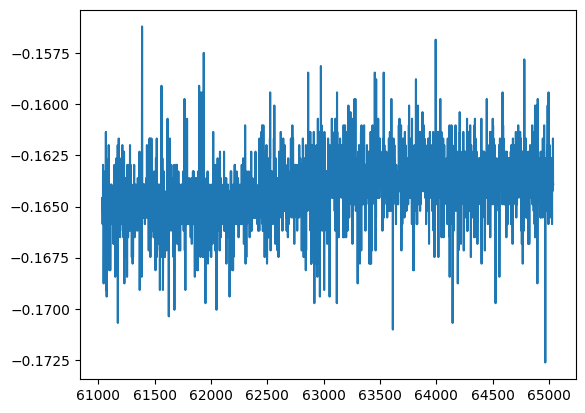

In [1169]:
s,e=61000-6000,65000-6000 #approx shift in index/time

plt.plot(time[s:e],field1[s:e])


In [1317]:
cutoffs

[120, 1181, 3234, 5321, 7165, 8908, 10559, 12213, 13662]

In [1277]:
magnet_back=[]
magnet_back_err=[]
for i in fields:
    change=np.mean(i[63500-6000:64000-6000]) - np.mean(i[61000-6000:62000-6000])
    changeerror=np.std(i[61500-6000:62000-6000])/np.sqrt(500) + np.std(i[64000-6000:65000-6000])/np.sqrt(500) #add errors
    magnet_back.append(change)
    magnet_back_err.append(changeerror)

for i in np.arange(len(fields)):
    print(f"Background due to magnet in fx{i+1}: {round(magnet_back[i],3)} +- {round(magnet_back_err[i],3)}")

print(magnet_back)

Background due to magnet in fx1: 0.00145 +- 0.000115
Background due to magnet in fx2: 0.00137 +- 0.000144
Background due to magnet in fx3: -0.00116 +- 0.000138
Background due to magnet in fx4: 0.00109 +- 0.000121
Background due to magnet in fx5: 0.000495 +- 0.000269
Background due to magnet in fx6: -0.00097 +- 2.58e-05
Background due to magnet in fx7: -0.000888 +- 2.18e-05
Background due to magnet in fx8: -0.00103 +- 2.72e-05
[0.001451836000000012, 0.0013650080000000009, -0.0011625690000000022, 0.0010884850000000001, 0.0004950519999999997, -0.0009703032499999709, -0.0008884087499999027, -0.0010287609999999892]


In [1334]:
#Calculating background for each field probe at each position
temp=avg_temps
n=60 #secs to get data from
cutoffs=gen_cutoff(time,temp,fields,n)
total_back = np.zeros((8,9))
for i in np.arange(len(fields)):
    total_back[i]=field_avg(time,fields[i],cutoffs,-22.5,n)[1] + magnet_back[i] #adding ambient background to the additional background from 8T magnet
print(total_back)


[[-0.00143648 -0.0014794  -0.00198398 -0.00170488 -0.00188735 -0.0015277
  -0.0019625  -0.00218791 -0.0018605 ]
 [-0.00131931 -0.00155549 -0.00149109 -0.00179169 -0.00188293 -0.00181849
  -0.00170574 -0.00163603 -0.00174873]
 [ 0.00126928  0.00120485  0.00130683  0.00131751  0.00089875  0.00144098
   0.00110823  0.00118335  0.00141418]
 [-0.00618528 -0.00629263 -0.00623893 -0.00627113 -0.00652338 -0.0068885
  -0.00619595 -0.00667911 -0.00624422]
 [-0.01294711 -0.01489035 -0.01526075 -0.0174564  -0.0194157  -0.02038198
  -0.02067188 -0.0214557  -0.02063963]
 [ 0.00272038  0.00272574  0.002766    0.00286801  0.00281163  0.00283712
   0.00281836  0.00282773  0.00277136]
 [ 0.0032143   0.00317134  0.00328542  0.00327333  0.00335518  0.00332567
   0.0033109   0.00334983  0.00333506]
 [ 0.00327522  0.00336782  0.00345374  0.00344433  0.00341883  0.00343493
   0.00343896  0.00346714  0.00346178]]


In [1545]:
room_temp_backs=[]
temp=sample_temps
cutoffs=gen_cutoff(time,temp,fields,n)
for i in np.arange(len(fields)):
    room_temp_backs.append(field_avg(time,fields[i],cutoffs,-22.5,n)[1][0])

print(room_temp_backs)

[-0.002888316666666667, -0.0026843166666666667, 0.0024318499999999993, 0.007273766666666666, -0.013442166666666668, -0.014762716666666667, -0.01641085, -0.017215933333333332]


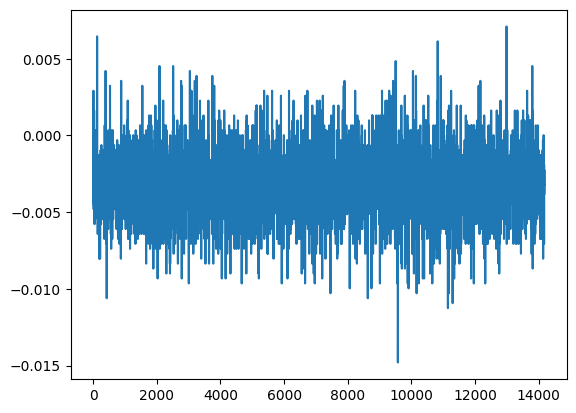

In [1315]:
plt.plot(time,fields[1])

0.9565512642108602


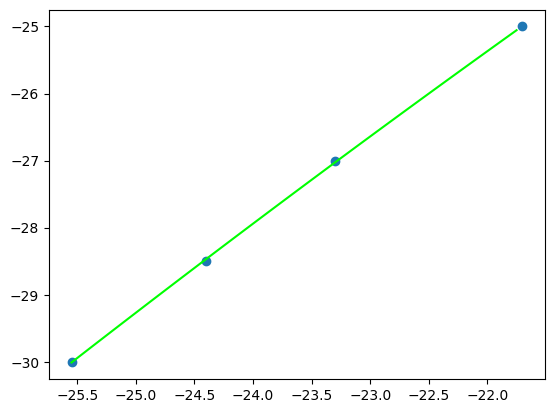

In [1182]:
#reverse engineer bath temp from real temp

bath_temps=[-25,-27,-28.5,-30]
real_temps=[-21.7,-23.3,-24.4,-25.55]
lock_in=[-136.25]
plt.scatter(real_temps,bath_temps)

z=np.arange(min(real_temps),max(real_temps),.1)
fit=np.polyfit(real_temps,bath_temps,2,full=True)

plt.plot(z,fit[0][0]*z**2+fit[0][1]*z+fit[0][2], color="lime")

print(fit[0][0]*-22.84+fit[0][1])

In [1173]:
np.std([-22.83,-22.76,-22.93])

0.06976149845485385

-137.46244361818822


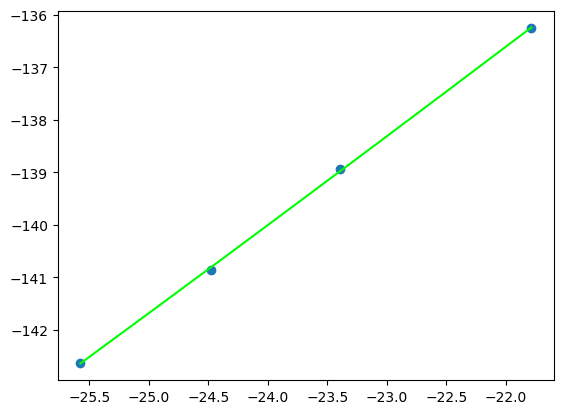

In [26]:
real_temps_1=np.float64([-21.7,-23.3,-24.4,-25.55])
real_temps_2=np.float64([-21.87,-23.489,-24.55,-25.6])
real_temps_3=[-21.75,-23.27,-24.42,-25.49]
real_temps_avg=[-21.79,-23.3,-24.46,-25.53]
real_temps_sample=(real_temps_1+real_temps_2)/2
lock_in=[-136.25,-138.94,-140.85,-142.62]

Tc=-22.5

real_temps=real_temps_sample

plt.scatter(real_temps,lock_in)

z=np.arange(min(real_temps),max(real_temps),.01)
fit=np.polyfit(real_temps,lock_in,2,full=True)

plt.plot(z,fit[0][0]*z**2+fit[0][1]*z+fit[0][2], color="lime")

print(fit[0][0]*Tc**2+fit[0][1]*Tc+fit[0][2])

In [37]:
total_back()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


array([[-0.00143648, -0.00155991, -0.0019571 , -0.0017639 , -0.0019142 ,
        -0.00158675, -0.0020645 , -0.00198391, -0.0018605 ],
       [-0.00131931, -0.00164139, -0.00144278, -0.00161989, -0.00185609,
        -0.00207618, -0.00171651, -0.00190438, -0.00174873],
       [ 0.00126928,  0.00111358,  0.00140346,  0.00138193,  0.00080748,
         0.00143563,  0.00127461,  0.00132828,  0.00141418],
       [-0.00618528, -0.00636778, -0.00629798, -0.00641607, -0.00646972,
        -0.00667378, -0.00635703, -0.00657716, -0.00624422],
       [-0.01294711, -0.0149172 , -0.01558286, -0.01721483, -0.0193781 ,
        -0.02027998, -0.02108525, -0.0208061 , -0.02063963],
       [ 0.00272038,  0.00272976,  0.00279016,  0.00287741,  0.00281566,
         0.00280088,  0.00285458,  0.00281566,  0.00277136],
       [ 0.0032143 ,  0.00315926,  0.00325723,  0.00328004,  0.00334445,
         0.00326796,  0.00337801,  0.00332568,  0.00333506],
       [ 0.00327522,  0.00335842,  0.00343496,  0.00346446,  0